## 03. Modeling — ESS 배터리 수명 예측 

**목표**
- **과제**: 02와 같은 피처 표로 회귀 모델을 선택하고 평가
- **타깃/지표**: `y = log10(cycle_life)`, 10의 제곱으로 되돌린 **MAPE(%)** (|예측 − 실제| / 실제의 평균)
- **분할**: 학습, 선택은 Batch1만 (프로토콜 단위 hold-out + GroupKFold CV)
- **테스트**: Batch2(1차), Batch3(선택)는 선택이 끝난 뒤 **한 번만**
- **실행**: 계산은 `src/train.py` 함수 호출. `python -m src.train`이 저장한 `results/` CSV는 읽어서 대조만 하고, 그림 3장만 다시 저장



In [2]:
import os, sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())          
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.features import CORE, build_feature_table, model_cells
from src import train as T               # 분할, 모델, CV, ablation, 성능 표, 오류 분석 함수
from src import plots                    # 그림 3종

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)
print(f"SEED={T.SEED} | hold-out 비율={T.HOLDOUT_FRAC} | 바깥 CV={T.N_OUTER}-fold"
      f" | 안쪽 CV={T.N_INNER}-fold | 목표 MAPE={T.TARGET_MAPE}% | 후보={T.CANDIDATES}")

SEED=42 | hold-out 비율=0.2 | 바깥 CV=4-fold | 안쪽 CV=3-fold | 목표 MAPE=9.1% | 후보=['ElasticNet', 'Ridge', 'RandomForest']


### 1. Batch1 hold-out 분할 

- **hold-out**(= Valid): 학습·선택에 전혀 안 쓰는 검증 셀. Batch1 36셀을 
- **프로토콜 단위**로 분할(같은 프로토콜이 양쪽에 있으면 Valid가 낙관적). 
- `GroupShuffleSplit(test_size=0.2, random_state=42)` 한 번, seed는 Batch2를 보기 전에 고정하고 바꿔 가며 다시 돌리지 않음.

In [3]:
# 피처 표 → 모델링 셀(제외 규칙 적용) → Batch1만 골라 프로토콜 단위로 분할
clean = model_cells(build_feature_table())
b1 = clean[clean.batch == "b1"]
train, hold = T.split_holdout(b1)

모델링 셀 수: {'b1': 36, 'b2': 39, 'b3': 44}
제외 이유 (nan_life = 수명 NaN, not_80pct_only = 수명은 있으나 80% 미도달):
       nan_life  not_80pct_only
batch                          
b1            0              10
b2            8               0
b3            2               0
[STEP 3] seed=42 | train 29셀 / 16프로토콜 | hold-out 7셀 / 4프로토콜
  hold-out 프로토콜별 셀 수: {'4.4C(80%)-4.4C': 1, '4.8C(80%)-4.8C': 2, '7C(40%)-3.6C': 2, '8C(15%)-3.6C': 2}
  hold-out 수명 범위: 617 ~ 1074


In [4]:
# 분할 요약 표: 셀 수, 프로토콜 수, 수명 범위
def split_row(name, d):
    return {"구분": name, "셀 수": len(d), "프로토콜 수": d.policy.nunique(),
            "수명 최소": int(d.cycle_life.min()), "수명 최대": int(d.cycle_life.max())}

split = pd.DataFrame([split_row("Train (학습·CV)", train),
                      split_row("Valid (hold-out)", hold),
                      split_row("Batch1 전체", b1)])
print(split.to_string(index=False))

print("\nhold-out 프로토콜:")
print(hold.groupby("policy").cycle_life.agg(["size", "min", "max"]).astype(int).to_string())
print("\ntrain·hold-out 프로토콜 겹침:", set(train.policy) & set(hold.policy))

              구분  셀 수  프로토콜 수  수명 최소  수명 최대
   Train (학습·CV)   29      16    534   1054
Valid (hold-out)    7       4    617   1074
       Batch1 전체   36      20    534   1074

hold-out 프로토콜:
                size   min   max
policy                          
4.4C(80%)-4.4C     1  1074  1074
4.8C(80%)-4.8C     2   636   870
7C(40%)-3.6C       2   617   625
8C(15%)-3.6C       2   966  1051

train·hold-out 프로토콜 겹침: set()


### 2. 모델 비교와 피처 ablation — Batch1 train 29셀의 CV만 사용

- 모델: Dummy(학습 평균 예측 기준선, 표에 `(none)`·채택 `-`), Ridge, ElasticNet, RandomForest(얕은 나무 고정). 
- `StandardScaler + 모델` Pipeline → 스케일러도 fold 학습 부분에만 fit.
- **중첩 CV**: 바깥 `GroupKFold(4)`(프로토콜 단위)로 점수, 안쪽 `GroupKFold(3)` GridSearchCV로 하이퍼파라미터(Ridge alpha, ElasticNet alpha·l1_ratio). 
- **ablation**: `dQ_log_var` → `+avgC_0to80_meas` → `+Tavg_mean_2_100`, **CV MAPE가 낮아질 때만** 유지, 최종 = CV MAPE 최저 (모델, 피처).

In [5]:
# comp = 단계별 CV 표, (name, feats, cv) = 선택된 모델 이름, 피처 목록, CV MAPE
comp, (name, feats, cv) = T.run_selection(train)
print("\n선택 결과:", name, feats, f"CV MAPE {cv:.2f}%")
print(comp.round(2).to_string(index=False))

  Dummy        step 1 (none)                                        CV MAPE  14.72%  -
  ElasticNet   step 1 dQ_log_var                                    CV MAPE   9.34%  채택
  ElasticNet   step 2 dQ_log_var+avgC_0to80_meas                    CV MAPE  10.16%  CV 기준 버림
  ElasticNet   step 3 dQ_log_var+Tavg_mean_2_100                    CV MAPE   9.89%  CV 기준 버림
  Ridge        step 1 dQ_log_var                                    CV MAPE   9.27%  채택
  Ridge        step 2 dQ_log_var+avgC_0to80_meas                    CV MAPE   9.85%  CV 기준 버림
  Ridge        step 3 dQ_log_var+Tavg_mean_2_100                    CV MAPE   9.79%  CV 기준 버림
  RandomForest step 1 dQ_log_var                                    CV MAPE  10.06%  채택
  RandomForest step 2 dQ_log_var+avgC_0to80_meas                    CV MAPE  10.81%  CV 기준 버림
  RandomForest step 3 dQ_log_var+Tavg_mean_2_100                    CV MAPE  10.63%  CV 기준 버림
[STEP 6] 최종 선택(Batch1 CV만으로): Ridge + ['dQ_log_var'] | CV MAPE 9.27%

선택 결과: Ridge ['

- **CV MAPE** (`dQ_log_var` 단독): Dummy 14.72% / Ridge 9.27% / ElasticNet 9.34% / RandomForest 10.06%
- **피처 추가**: `avgC_0to80_meas`, `Tavg_mean_2_100`를 더하면 모든 모델에서 CV 상승 (Ridge 9.27 → 9.85 / 9.79) → 버림
- **선택**: Ridge + `dQ_log_var` 단독, CV MAPE 9.27% (Batch1 학습 29셀 CV만으로 선택)
- 이후: hold-out, Batch2, Batch3는 아래에서 처음 사용


> **평가 원칙**
> - 모델, 피처, 하이퍼파라미터·seed·분할은 2절에서 **확정**. Batch2/3는 그 뒤 **한 번만** 평가했고, 결과를 보고 다시 고르거나 튜닝하지 않음.
> - `model_comparison`의 hold-out·Batch2 열은 **기록용**(선택에 안 씀).
> - Valid(hold-out)는 **7셀·4프로토콜**뿐이라 잡음이 큼 → Valid 하나로 과적합 여부를 단정하지 않음.

### 3. 최종 평가와 성능 표 (`T.fit_model` → `T.predict_table` → `T.performance_table`)

- refit: 최종 모델은 train 29셀에만 fit, **같은 모델**로 Valid, Test 측정(hold-out을 다시 넣으면 Valid와 Test가 다른 모델의 점수가 됨).
- **Gap 부호 규칙**: Gap = 뒤 항목 MAPE − 앞 항목 MAPE (행 이름의 앞−뒤 순서와 반대), (+) = 오차 증가. 예: `Gap (Valid-Test)` = Test − Valid.

**3-1. 최종 모델 학습과 성능 표**

In [7]:
b2 = clean[clean.batch == "b2"]
b3 = clean[clean.batch == "b3"]
final = T.fit_model(name, train[feats], train.logL, train.policy)
print("최종 모델:", name, feats, "| 하이퍼파라미터:", final.best_params_)

# 셀별 예측 표 
pred_ho = T.predict_table(final, feats, hold)
pred2 = T.predict_table(final, feats, b2)
pred3 = T.predict_table(final, feats, b3)
perf = T.performance_table(cv, pred_ho.abs_pct_err.mean(),
                           pred2.abs_pct_err.mean(), pred3.abs_pct_err.mean())
print("Gap 부호 규칙:", T.GAP_RULE)
display(perf.iloc[:6])                   

최종 모델: Ridge ['dQ_log_var'] | 하이퍼파라미터: {'model__alpha': 0.01}
Gap 부호 규칙: Gap = 뒤 항목 MAPE − 앞 항목 MAPE (행 이름의 앞−뒤 순서와 반대), (+) = 오차 증가


,구분,MAPE (%),비고
0,Train (Batch1 CV),9.27,프로토콜 GroupKFold 4-fold 평균 (중첩 CV)
1,Valid (Batch1 Hold-out),8.47,프로토콜 단위 hold-out
2,Test (Batch2),29.60,"1차 테스트셋 최종 성능 (39셀, 돌출 셀 포함)"
3,Gap (Train-Valid),-0.80,"Valid − Train. (+) : 과적합 의심 [Gap = 뒤 항목 MAPE − 앞 항목 MAPE (행 이름의 앞−뒤 순서와 반대),..."
4,Gap (Valid-Test),21.14,Test − Valid. (+) : 배치 간 일반화 저하 의심 [Gap = 뒤 항목 MAPE − 앞 항목 MAPE (행 이름의 앞−뒤 순...
5,Gap (Target-Test),20.50,Test − Target. (+): 목표 미달; Target : 원논문 9.1% [Gap = 뒤 항목 MAPE − 앞 항목 MAPE (행...


**3-2. `results/` 에 저장된 표(`python -m src.train` 결과)와 대조**

In [8]:
saved = pd.read_csv(os.path.join(T.RESULTS_DIR, "model_performance.csv"))
print("results/model_performance.csv 와 MAPE 열 일치:",
      np.allclose(saved["MAPE (%)"], perf["MAPE (%)"]))

results/model_performance.csv 와 MAPE 열 일치: True


- **MAPE**: Train(CV) 9.27%, Valid 8.47%, **Test(Batch2) 29.60%** (목표 9.1% 미달)
- **Gap (Train-Valid)** −0.80: Valid가 7셀이라 잡음 범위 (5절)
- **Gap (Valid-Test)** +21.14: 배치 간 일반화 저하 의심
- **Gap (Target-Test)** +20.50: 원논문 9.1%보다 20.5%p 나쁨
- **해석**: Batch1 안에서는 과적합 신호가 없고 Batch2에서만 나빠짐. 모델 복잡도보다 Batch2 셀이 학습 셀과 다른 점이 원인일 가능성 (6절)


### 4. Batch3 추가 표와 ΔQ 돌출 셀 민감도 (`T.sensitivity_table`)

Batch3 = 과제 선택 항목(2차 테스트셋). 돌출 셀 민감도는 **확인 전용**, 선택에 안 씀(성능 표엔 돌출 셀 포함).

In [9]:
print("Gap 부호 규칙:", T.GAP_RULE)
display(perf.iloc[6:])                   # 뒤 3행: Test(Batch3)와 Gap 2개

sens = T.sensitivity_table(pred2, pred3)
print("ΔQ 돌출 셀 민감도 (선택에 사용 안 함):")
print(sens.to_string(index=False))

Gap 부호 규칙: Gap = 뒤 항목 MAPE − 앞 항목 MAPE (행 이름의 앞−뒤 순서와 반대), (+) = 오차 증가


,구분,MAPE (%),비고
6,Test (Batch3),12.22,"선택: 2차 테스트셋 (44셀, 돌출 셀 포함)"
7,Gap (Batch2-Batch3),-17.39,"선택: Batch3 − Batch2. (+) : Batch3 오차가 Batch2보다 큼, (−) : Batch3 오차가 더 작음 [Gap..."
8,Gap (Target-Test Batch3),3.12,선택: Test(Batch3) − Target. (+): 목표 미달; Target : 원논문 9.1% [Gap = 뒤 항목 MAPE − ...


ΔQ 돌출 셀 민감도 (선택에 사용 안 함):
 batch  n_all  mape_all  n_protrusion  n_without  mape_without_protrusion
Batch2     39     29.60             4         35                    30.74
Batch3     44     12.22             8         36                    10.77


- **Test(Batch3)** 12.22%
- **Gap (Batch2-Batch3)** −17.39: Batch3 오차가 17.39%p 작음 (Batch3 − Batch2)
- **Gap (Target-Test Batch3)** +3.12: 목표 9.1%에 3.12%p 미달
- **돌출 셀 제외**: Batch2 29.60 → 30.74% (4셀, 오히려 약간 악화), Batch3 12.22 → 10.77% (8셀)
- **해석**: 돌출 셀은 Batch2의 큰 오차를 설명하지 못함. 원인은 다른 곳 (셀 구조, 학습 범위)


### 5. Valid(hold-out 7셀)가 얼마나 흔들리는가 

선택 후, train 29셀에서 **프로토콜 하나씩 빼고**(leave-one-protocol-out) 같은 방식(`T.fit_model`, Ridge + `dQ_log_var`)으로 학습해 빠진 프로토콜 MAPE 측정. 흔들림 확인용, **선택에 안 씀**, Batch2/3 미사용.

In [10]:
lopo = []
for pol in train.policy.unique():
    train_part = train[train.policy != pol]          # 이 프로토콜을 뺀 나머지로 학습
    val_part = train[train.policy == pol]            # 뺀 프로토콜로 평가
    model = T.fit_model(name, train_part[feats], train_part.logL, train_part.policy)
    lopo.append({"policy": pol, "n": len(val_part),
                 "mape": T.mape(val_part.cycle_life, model.predict(val_part[feats]))})
lopo = pd.DataFrame(lopo)
print(f"프로토콜 {len(lopo)}개 | MAPE 최소 {lopo.mape.min():.2f}% / 최대 {lopo.mape.max():.2f}%"
      f" / 표준편차 {lopo.mape.std():.2f}%p")

# 실제 hold-out 4개 프로토콜 각각의 MAPE (최종 모델)
print("hold-out 프로토콜별 MAPE(%):",
      pred_ho.groupby("protocol").abs_pct_err.mean().round(2).to_dict())

프로토콜 16개 | MAPE 최소 1.56% / 최대 26.35% / 표준편차 5.64%p
hold-out 프로토콜별 MAPE(%): {'4.4C(80%)-4.4C': 8.27, '4.8C(80%)-4.8C': 14.83, '7C(40%)-3.6C': 1.64, '8C(15%)-3.6C': 9.04}


- **프로토콜 하나씩 빼고 잰 MAPE**: 1.56% ~ 26.35% (표준편차 5.64%p)
- **실제 hold-out 4개 프로토콜**: 1.64% ~ 14.83%, Valid 8.47%는 이 7셀의 평균
- **해석**: Valid 8.47%와 Train 9.27%의 차이(−0.80%p)는 이 흔들림보다 훨씬 작음. **Valid는 잡음이 큰 값**이라 Train(CV)과 함께 읽음


### 6. 오류 분석 (`T.error_summary`)

테스트 셀을 (a) 셀 구조(기존 vs `newstructure` 표기), (b) 실제 수명이 학습 범위(534 ~ 1,054) 아래/안/위로 나눔. 원인 설명은 **가설**, [describe]엔 숫자로 확인된 것만.

**6-1. Batch2: 가장 크게 틀린 셀과 셀 무리별 오차**

In [12]:
# 학습 셀(29셀)의 수명 범위 = 오류 분석의 '아래/안/위' 기준
train_range = (train.cycle_life.min(), train.cycle_life.max())
print(f"학습 셀(29셀) 범위 {train_range[0]:.0f}~{train_range[1]:.0f}"
      f" | Batch1 전체(36셀) 범위 {b1.cycle_life.min():.0f}~{b1.cycle_life.max():.0f}")
print("--- Batch2")
p2 = T.error_summary(pred2, train_range)  # 최악 5셀, 무리별 평균 오차, 과대예측 비율 출력

학습 셀(29셀) 범위 534~1054 | Batch1 전체(36셀) 범위 534~1074
--- Batch2
  가장 크게 틀린 5셀:
cell_id        protocol  newstructure  protrusion life_vs_train  y_true  y_pred  abs_pct_err
   b2c6     3.6C(9%)-5C         False       False         below   393.0   653.9         66.4
  b2c15     3.6C(9%)-5C         False       False         below   396.0   648.2         63.7
  b2c18 5.2C(50%)-4.25C         False       False         below   449.0   731.4         62.9
   b2c2 5.2C(50%)-4.25C         False       False         below   424.0   625.7         47.6
  b2c19      6C(60%)-3C         False       False         below   392.0   562.6         43.5
  newstructure 여부별 평균 오차(%): {False: {'size': 30, 'mean': 33.9}, True: {'size': 9, 'mean': 15.4}}
  학습 수명 범위(534~1054) 대비 위치별 평균 오차(%): {'above': {'size': 2, 'mean': 6.1}, 'below': {'size': 30, 'mean': 33.9}, 'inside': {'size': 7, 'mean': 18.0}}
  예측 > 실제(과대예측) 비율: 92%


In [13]:
def group_table(p):
    # 셀 무리별: 셀 수, 수명 범위, MAPE, 과대예측 셀 수, 평균 log10 오차(+ = 과대예측), 전체 오차 중 비중
    g = p.assign(over=p.y_pred > p.y_true, log_err=np.log10(p.y_pred) - np.log10(p.y_true))
    out = g.groupby(["newstructure", "life_vs_train"]).agg(
        n=("cell_id", "size"), life_min=("y_true", "min"), life_max=("y_true", "max"),
        mape=("abs_pct_err", "mean"), n_over=("over", "sum"), mean_log_err=("log_err", "mean"),
        err_sum=("abs_pct_err", "sum"))
    out["err_share_%"] = 100 * out.err_sum / p.abs_pct_err.sum()
    return out.drop(columns="err_sum").round(3)

print("Batch2 셀 무리별 표:")
print(group_table(p2).to_string())

Batch2 셀 무리별 표:
                             n  life_min  life_max    mape  n_over  mean_log_err  err_share_%
newstructure life_vs_train                                                                   
False        below          30     392.0     514.0  33.876      30         0.125       88.026
True         above           2    1140.0    1186.0   6.071       0        -0.028        1.052
             inside          7     777.0    1029.0  18.014       6         0.067       10.922


In [14]:
# 기존 구조 30셀 vs newstructure 9셀 요약
old2, new2 = p2[~p2.newstructure], p2[p2.newstructure]
n_over_old = int((old2.y_pred > old2.y_true).sum())
log_err_old = np.mean(np.log10(old2.y_pred) - np.log10(old2.y_true))
share_old = 100 * old2.abs_pct_err.sum() / p2.abs_pct_err.sum()
print(f"\n기존 구조 {len(old2)}셀: MAPE {old2.abs_pct_err.mean():.2f}%, "
      f"과대예측 {n_over_old}/{len(old2)}, 평균 log10 오차 {log_err_old:+.3f}, "
      f"전체 절대 % 오차 중 비중 {share_old:.0f}%")
print(f"newstructure {len(new2)}셀: MAPE {new2.abs_pct_err.mean():.2f}%, "
      f"수명 {new2.y_true.min():.0f}~{new2.y_true.max():.0f}")
print(f"Batch2 전체 과대예측: {int((p2.y_pred > p2.y_true).sum())}/{len(p2)}")


기존 구조 30셀: MAPE 33.88%, 과대예측 30/30, 평균 log10 오차 +0.125, 전체 절대 % 오차 중 비중 88%
newstructure 9셀: MAPE 15.36%, 수명 777~1186
Batch2 전체 과대예측: 36/39


**Batch2** (39셀, MAPE 29.60%, 36셀 과대예측)
- **기존 구조 30셀**: 수명 392 ~ 514로 모두 학습 최솟값(534)보다 짧음. 전부 과대예측, MAPE 33.88%, 평균 log10 오차 +0.125(약 1.33배 길게). Batch2 절대 % 오차의 약 88%. 최악 5셀(b2c6, b2c15, b2c18, b2c2, b2c19)도 여기이고 +44 ~ +66%
- **newstructure 9셀**: 수명 777 ~ 1,186, MAPE 15.36% (범위 안 7셀 18.01%, 범위 위 2셀 6.07%). 범위 위 2셀은 과소예측


**6-2. Batch2 진단: 피처-수명 관계와 체계적 편향 (해석용)**

In [15]:
# 피처가 기존 구조 셀 안에서도 수명 순서를 잡는가: 학습 셀과 같은 상관을 비교
old_b2 = b2[~b2.newstructure]
r_old = np.corrcoef(old_b2[CORE], old_b2.logL)[0, 1]
r_train = np.corrcoef(train[CORE], train.logL)[0, 1]
print(f"{CORE} vs log10(수명) r: 학습 29셀 {r_train:.2f} | Batch2 기존 구조 30셀 {r_old:.3f}")

# 진단 지표(결과 아님): Batch2 정답으로 '상수 log 보정값 하나'를 빼 준다면 MAPE가 얼마까지 내려가나
offset = np.mean(np.log10(p2.y_pred) - np.log10(p2.y_true))
mape_oracle = np.mean(np.abs(p2.y_pred / 10 ** offset - p2.y_true) / p2.y_true) * 100
print(f"[진단 전용] Batch2 정답을 보고 고른 상수 log 보정({offset:+.3f}) 후 MAPE ≈ {mape_oracle:.1f}%"
      "  ← 체계적 편향의 크기 지표, 성능 결과가 아님")

dQ_log_var vs log10(수명) r: 학습 29셀 -0.81 | Batch2 기존 구조 30셀 -0.375
[진단 전용] Batch2 정답을 보고 고른 상수 log 보정(+0.106) 후 MAPE ≈ 10.2%  ← 체계적 편향의 크기 지표, 성능 결과가 아님


- **상관**: `dQ_log_var`와 log 수명의 상관은 학습 셀 −0.81, Batch2 기존 구조 30셀 안에서는 **−0.375**(약함)
- **진단 지표**: Batch2 정답을 보고 고른 상수 log 보정 하나만 빼도 MAPE가 약 10.2%. 오차의 상당 부분이 한 방향 편향이라는 뜻이며, 정답을 써서 만든 값이라 **성능 결과가 아님** (보고 표에 안 씀)

**가설** 
- **셀 구조 차이**: 기존 구조 Batch2 셀은 같은 ΔQ 분산에서 학습 셀보다 수명이 짧음. 셀 구조나 시험 시기가 관계를 바꿨을 수 있음
- **학습 범위 잘림**: 80% 미도달 Batch1 10셀을 제외해 범위가 534 ~ 1,054. 범위 밖(짧은 쪽 30셀, 긴 쪽 2셀)은 외삽
- **평균으로의 회귀**: 관계가 약해지면 예측이 학습 평균 쪽으로 몰림 (짧은 셀은 과대예측, 범위 위 셀은 과소예측과 같은 방향)


**6-3. Batch3: 가장 크게 틀린 셀과 셀 무리별 오차**

In [16]:
print("--- Batch3")
p3 = T.error_summary(pred3, train_range)
print("\nBatch3 셀 무리별 표:")
print(group_table(p3).to_string())

above3 = p3[p3.life_vs_train == "above"]          # 학습 범위 위(수명 > 1054) 셀
n_under = int((above3.y_pred < above3.y_true).sum())
print(f"\n범위 위 {len(above3)}셀 중 과소예측(예측 < 실제): {n_under}셀")

--- Batch3
  가장 크게 틀린 5셀:
cell_id                    protocol  newstructure  protrusion life_vs_train  y_true  y_pred  abs_pct_err
  b3c38     5C(67%)-4C-newstructure          True        True         above  1935.0  1092.2         43.6
   b3c7 4.8C(80%)-4.8C-newstructure          True       False         above  1836.0  1198.3         34.7
  b3c42 4.8C(80%)-4.8C-newstructure          True        True         above  1642.0  1095.1         33.3
  b3c40 5.6C(19%)-4.6C-newstructure          True       False        inside   796.0  1060.3         33.2
  b3c45 4.8C(80%)-4.8C-newstructure          True       False         above  1801.0  1222.8         32.1
  newstructure 여부별 평균 오차(%): {True: {'size': 44, 'mean': 12.2}}
  학습 수명 범위(534~1054) 대비 위치별 평균 오차(%): {'above': {'size': 17, 'mean': 16.9}, 'inside': {'size': 27, 'mean': 9.3}}
  예측 > 실제(과대예측) 비율: 52%

Batch3 셀 무리별 표:
                             n  life_min  life_max    mape  n_over  mean_log_err  err_share_%
newstructure life_vs_train      

[describe] Batch3 (44셀, MAPE 12.22%): **모두 newstructure**, 학습 범위 아래 셀 **없음**. 범위 안 27셀 MAPE 9.28%(≈ Batch1 CV 9.27%), 범위 위 17셀 16.88%, 17셀 중 13셀 과소예측. 최악 5셀 중 4셀이 수명 1,642 ~ 1,935의 범위 위 셀.

[to modeling] 범위 안은 Batch3도 Batch1 수준, 오차는 **학습 범위 밖**(Batch2 아래, Batch3 위)에서 커짐. 개선 방향(이번 과제에선 미적용 — 테스트 결과를 보고 고치면 누수): 더 넓은 수명 범위 학습 셀, 검열 셀을 버리지 않는 생존분석형 타깃, 셀 구조를 반영할 학습 데이터.


### 7. 그림 3장 (`plots.make_all`)

`results/figures/`에 저장: `M1_pred_vs_actual.png`, `M2_error_by_cell.png`, `M3_ablation.png`.

In [17]:
# hold-out·Batch2 MAPE를 기록용 열로 붙인 비교 표 (선택에 안 씀) → 저장된 CSV와 대조
comp_rec = T.record_comparison(comp, train, hold, b2)
saved_comp = pd.read_csv(os.path.join(T.RESULTS_DIR, "model_comparison.csv"))
num_cols = ["cv_mape", "holdout_mape", "b2_mape_recorded_only"]
print("results/model_comparison.csv 와 숫자 열 일치:",
      np.allclose(saved_comp[num_cols], comp_rec[num_cols]))
plots.make_all(pred2, pred3, comp_rec, train_range)

results/model_comparison.csv 와 숫자 열 일치: True
그림 저장: results/figures ['M1_pred_vs_actual.png', 'M2_error_by_cell.png', 'M3_ablation.png']


**7-1. M1 예측 vs 실제**

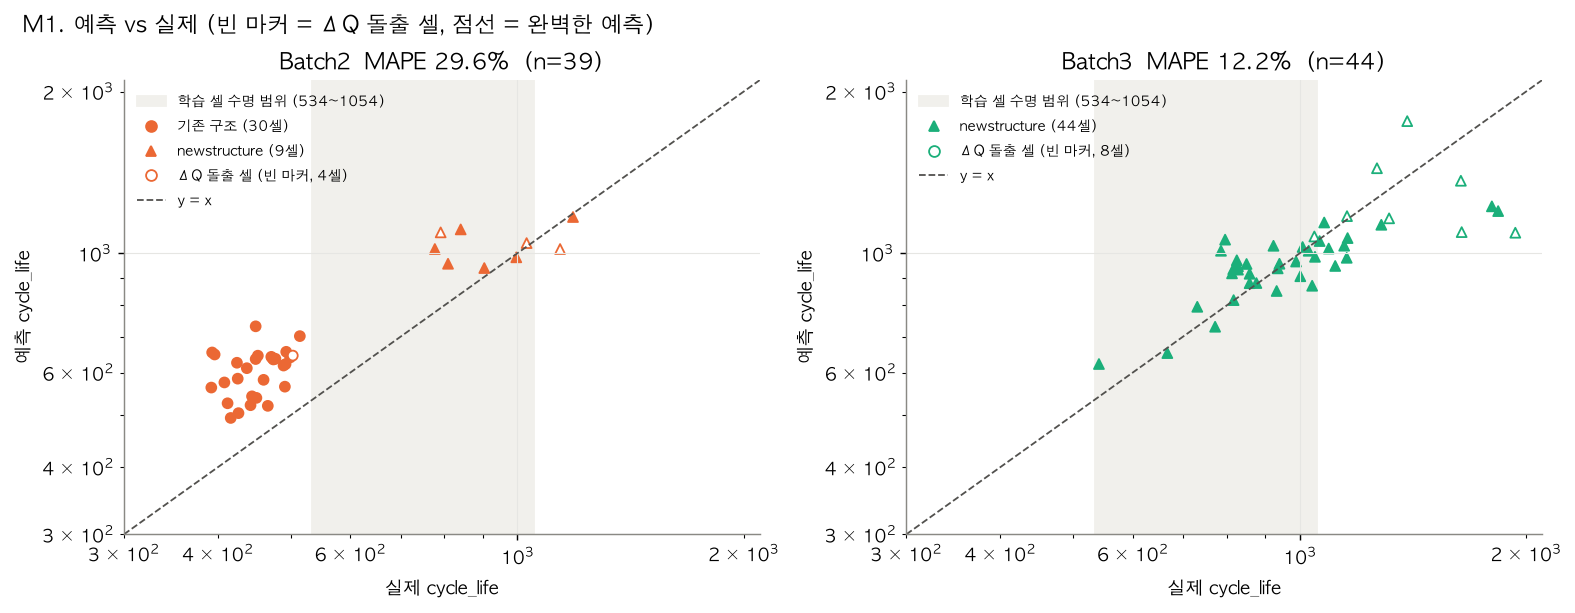

In [18]:
display(Image(os.path.join(plots.FIG_DIR, "M1_pred_vs_actual.png")))

- **Batch2 (왼쪽)**: 기존 구조 원 30개는 모두 학습 범위(회색 띠)의 왼쪽, 대각선 위쪽에 있음 → 단수명 과대예측. newstructure 세모 9개는 대각선에 더 가까움 (MAPE 15.36% vs 33.88%)
- **Batch3 (오른쪽)**: 범위 오른쪽 세모 17개 중 13개가 대각선 아래 → 장수명 과소예측, 1,600 이상에서 가장 큼


**7-2. M2 셀별 오차**

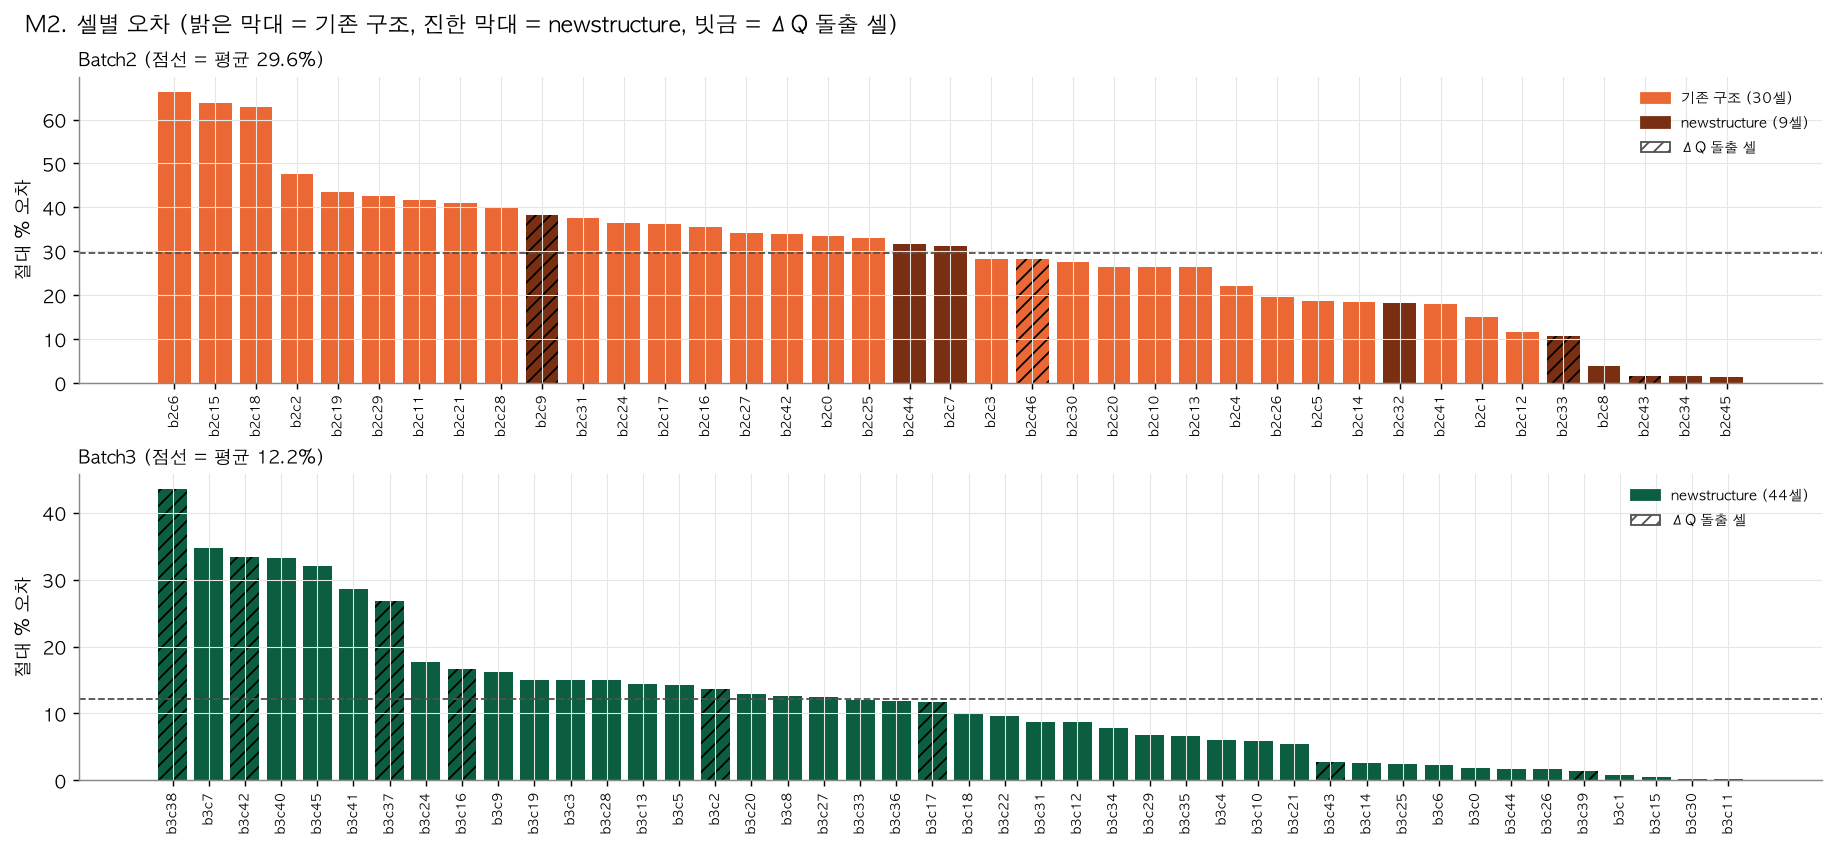

In [19]:
display(Image(os.path.join(plots.FIG_DIR, "M2_error_by_cell.png")))

- **Batch2**: 오차 상위 9셀이 모두 밝은 막대(기존 구조). 진한 막대(newstructure)와 빗금(돌출 셀)은 중간 이하
- **Batch3**: 전부 newstructure(진한 초록). 오차 상위 5셀 중 4셀이 학습 범위 위의 장수명 셀


**7-3. M3 ablation**

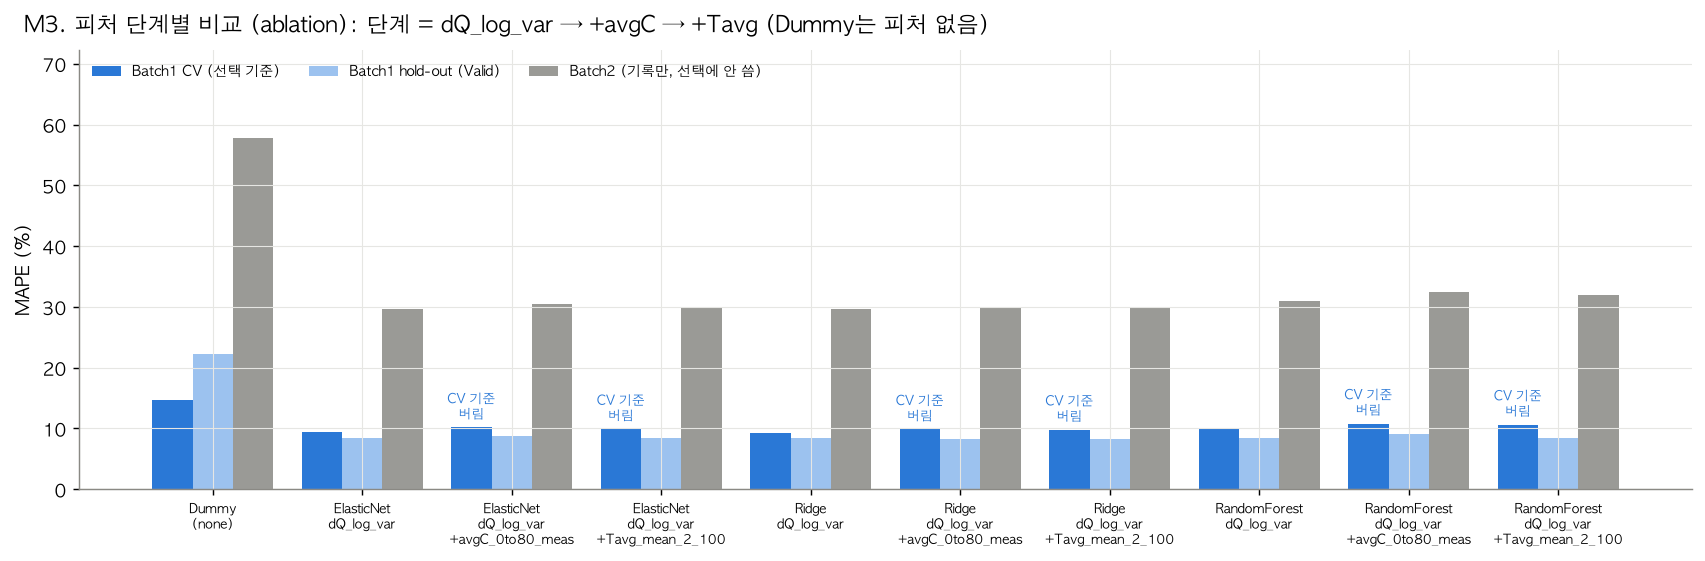

In [20]:
display(Image(os.path.join(plots.FIG_DIR, "M3_ablation.png")))

- **파랑 막대(Batch1 CV)**: 선택 기준. `+avgC`, `+Tavg`는 모든 모델에서 CV가 올라 'CV 기준 버림'. Dummy는 피처 없는 기준선
- **회색 막대(Batch2)**: 기록만 하고 선택에는 안 씀. Dummy를 뺀 모든 조합이 약 30%(29.6 ~ 32.5) → 피처를 바꿨어도 Batch2 문제는 남았을 것으로 보임


### 8. 정리

- **목적**: Batch1만으로 모델을 선택하고 Batch2, Batch3에서 한 번 평가
- **방법**: 프로토콜 단위 hold-out과 중첩 GroupKFold CV, ablation, 선택 후 1회 평가
- **결과**: Dummy CV 14.72% → Ridge + `dQ_log_var` CV 9.27%, Valid 8.47%, **Batch2 29.60%**, Batch3 12.22%
- **시사점**: 학습 범위 안의 셀은 Batch1 수준(Batch3 범위 안 9.28%). Batch2 오차의 약 88%는 범위 아래 기존 구조 30셀(모두 과대예측)에서 나옴. 원인(셀 구조, 학습 범위 잘림, 평균으로의 회귀)은 가설
